In [1]:
# COVID-19 API Data Pipeline
# Data Source: disease.sh (Open Disease Data API)
# Author: Anshika Sharma

import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# Global totals
url_global = "https://disease.sh/v3/covid-19/all"

response = requests.get(url_global)
global_data = response.json()

print("Global COVID-19 Summary")
print(f"  Total Cases:     {global_data['cases']:,}")
print(f"  Total Deaths:    {global_data['deaths']:,}")
print(f"  Total Recovered: {global_data['recovered']:,}")
print(f"  Active Cases:    {global_data['active']:,}")
print(f"\nAPI Status: {response.status_code}")

Global COVID-19 Summary
  Total Cases:     704,753,890
  Total Deaths:    7,010,681
  Total Recovered: 675,619,811
  Active Cases:    22,123,398

API Status: 200


In [3]:
# Country-level data
url_countries = "https://disease.sh/v3/covid-19/countries"

response_c = requests.get(url_countries)
countries_raw = response_c.json()

print(f"Countries fetched: {len(countries_raw)}")
print(f"Sample keys: {list(countries_raw[0].keys())}")

Countries fetched: 231
Sample keys: ['updated', 'country', 'countryInfo', 'cases', 'todayCases', 'deaths', 'todayDeaths', 'recovered', 'todayRecovered', 'active', 'critical', 'casesPerOneMillion', 'deathsPerOneMillion', 'tests', 'testsPerOneMillion', 'population', 'continent', 'oneCasePerPeople', 'oneDeathPerPeople', 'oneTestPerPeople', 'activePerOneMillion', 'recoveredPerOneMillion', 'criticalPerOneMillion']


In [4]:
records = []

for country in countries_raw:
    records.append({
        "country":            country.get("country"),
        "continent":          country.get("continent"),
        "population":         country.get("population"),
        "cases":              country.get("cases"),
        "deaths":             country.get("deaths"),
        "recovered":          country.get("recovered"),
        "active":             country.get("active"),
        "critical":           country.get("critical"),
        "tests":              country.get("tests"),
        "cases_per_million":  country.get("casesPerOneMillion"),
        "deaths_per_million": country.get("deathsPerOneMillion"),
        "tests_per_million":  country.get("testsPerOneMillion"),
        "updated":            datetime.fromtimestamp(country["updated"] / 1000).strftime("%Y-%m-%d %H:%M:%S")
    })

df = pd.DataFrame(records)

print(f"Shape: {df.shape}")
print(f"\nColumn dtypes:\n{df.dtypes}")
df.head(3)

Shape: (231, 13)

Column dtypes:
country               object
continent             object
population             int64
cases                  int64
deaths                 int64
recovered              int64
active                 int64
critical               int64
tests                  int64
cases_per_million      int64
deaths_per_million     int64
tests_per_million      int64
updated               object
dtype: object


,country,continent,population,cases,deaths,recovered,active,critical,tests,cases_per_million,deaths_per_million,tests_per_million,updated
0,Afghanistan,Asia,40754388,234174,7996,211080,15098,0,1390730,5746,196,34125,2026-07-01 06:37:33
1,Albania,Europe,2866374,334863,3605,330233,1025,0,1941032,116825,1258,677173,2026-07-01 06:37:33
2,Algeria,Africa,45350148,272010,6881,183061,82068,0,230960,5998,152,5093,2026-07-01 06:37:33


In [5]:
print("=== Null Check ===")
print(df.isnull().sum())

print(f"\n=== Basic Stats ===")
print(df[["cases", "deaths", "recovered", "tests"]].describe())

=== Null Check ===
country               0
continent             0
population            0
cases                 0
deaths                0
recovered             0
active                0
critical              0
tests                 0
cases_per_million     0
deaths_per_million    0
tests_per_million     0
updated               0
dtype: int64

=== Basic Stats ===
              cases        deaths     recovered         tests
count  2.310000e+02  2.310000e+02  2.310000e+02  2.310000e+02
mean   3.050883e+06  3.034927e+04  2.426700e+06  3.041777e+07
std    1.002125e+07  1.092314e+05  9.196220e+06  1.154321e+08
min    9.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00
25%    2.636600e+04  1.855000e+02  2.189500e+03  2.260585e+05
50%    2.068970e+05  1.974000e+03  5.894700e+04  1.690934e+06
75%    1.348198e+06  1.428700e+04  1.032544e+06  1.169128e+07
max    1.118201e+08  1.219487e+06  1.098144e+08  1.186852e+09


In [6]:
# Avoid division by zero
df["mortality_rate"]  = (df["deaths"] / df["cases"].replace(0, pd.NA) * 100).round(2)
df["recovery_rate"]   = (df["recovered"] / df["cases"].replace(0, pd.NA) * 100).round(2)
df["testing_rate"]    = (df["tests"] / df["population"].replace(0, pd.NA) * 100).round(2)
df["active_rate"]     = (df["active"] / df["cases"].replace(0, pd.NA) * 100).round(2)

print("Derived columns added ✓")
df[["country", "cases", "mortality_rate", "recovery_rate", "testing_rate", "active_rate"]].head(8)

Derived columns added ✓


,country,cases,mortality_rate,recovery_rate,testing_rate,active_rate
0,Afghanistan,234174,3.41,90.14,3.412467,6.45
1,Albania,334863,1.08,98.62,67.717332,0.31
2,Algeria,272010,2.53,67.30,0.509282,30.17
3,Andorra,48015,0.34,0.00,322.525593,99.66
4,Angola,107327,1.80,96.36,4.281784,1.84
5,Anguilla,3904,0.31,0.00,337.373605,99.69
6,Antigua and Barbuda,9106,1.60,98.33,18.994262,0.07
7,Argentina,10128845,1.29,98.70,77.626358,0.01


In [7]:
# Fill NaN from divide-by-zero with 0
derived_cols = ["mortality_rate", "recovery_rate", "testing_rate", "active_rate"]
df[derived_cols] = df[derived_cols].fillna(0)

# Drop rows where cases = 0 (uninformative)
before = len(df)
df = df[df["cases"] > 0].reset_index(drop=True)
after = len(df)

print(f"Rows removed (cases=0): {before - after}")
print(f"Final shape: {df.shape}")
print(f"\nNull check after clean:\n{df[derived_cols].isnull().sum()}")

Rows removed (cases=0): 0
Final shape: (231, 17)

Null check after clean:
mortality_rate    0
recovery_rate     0
testing_rate      0
active_rate       0
dtype: int64


/tmp/ipykernel_2090/886606968.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[derived_cols] = df[derived_cols].fillna(0)


In [8]:
print("=== Top 5 by Mortality Rate ===")
print(df[["country", "cases", "deaths", "mortality_rate"]]
      .sort_values("mortality_rate", ascending=False)
      .head(5).to_string(index=False))

print("\n=== Top 5 by Recovery Rate ===")
print(df[["country", "cases", "recovered", "recovery_rate"]]
      .sort_values("recovery_rate", ascending=False)
      .head(5).to_string(index=False))

print("\n=== Top 5 by Testing Rate (%) ===")
print(df[["country", "population", "tests", "testing_rate"]]
      .sort_values("testing_rate", ascending=False)
      .head(5).to_string(index=False))

=== Top 5 by Mortality Rate ===
             country  cases  deaths  mortality_rate
          MS Zaandam      9       2           22.22
               Yemen  11945    2159           18.07
      Western Sahara     10       1           10.00
               Sudan  63993    5046            7.89
Syrian Arab Republic  57743    3165            5.48

=== Top 5 by Recovery Rate ===
                      country    cases  recovered  recovery_rate
  Falkland Islands (Malvinas)     1930       1930         100.00
Holy See (Vatican City State)       29         29         100.00
                     N. Korea  4772813    4772739         100.00
                    Singapore  3006155    3004131          99.93
                     S. Korea 34571873   34535939          99.90

=== Top 5 by Testing Rate (%) ===
  country  population     tests  testing_rate
  Austria     9066710 211273524   2330.211554
  Denmark     5834950 129333107   2216.524683
      UAE    10081785 200732262   1991.038908
  Bermuda      

In [9]:
df["snapshot_date"] = datetime.now().strftime("%Y-%m-%d")

print(f"Snapshot date added: {df['snapshot_date'].iloc[0]}")
print(f"\nFinal columns ({len(df.columns)}):")
print(list(df.columns))

Snapshot date added: 2026-07-01

Final columns (18):
['country', 'continent', 'population', 'cases', 'deaths', 'recovered', 'active', 'critical', 'tests', 'cases_per_million', 'deaths_per_million', 'tests_per_million', 'updated', 'mortality_rate', 'recovery_rate', 'testing_rate', 'active_rate', 'snapshot_date']


In [10]:
conn = sqlite3.connect("covid_pipeline.db")

df.to_sql("covid_countries", conn, if_exists="replace", index=False)

print("Data loaded into SQLite ✓")
print(f"Table: covid_countries | Rows: {len(df)} | Columns: {len(df.columns)}")

Data loaded into SQLite ✓
Table: covid_countries | Rows: 231 | Columns: 18


In [11]:
query1 = """
SELECT country, continent, cases, deaths, recovered,
       ROUND(mortality_rate, 2) AS mortality_rate
FROM covid_countries
ORDER BY cases DESC
LIMIT 10
"""

top_cases = pd.read_sql_query(query1, conn)
print("=== Top 10 Countries by Total Cases ===")
print(top_cases.to_string(index=False))

=== Top 10 Countries by Total Cases ===
 country     continent     cases  deaths  recovered  mortality_rate
     USA North America 111820082 1219487  109814428            1.09
   India          Asia  45035393  533570          0            1.18
  France        Europe  40138560  167642   39970918            0.42
 Germany        Europe  38828995  183027   38240600            0.47
  Brazil South America  38743918  711380   36249161            1.84
S. Korea          Asia  34571873   35934   34535939            0.10
   Japan          Asia  33803572   74694          0            0.22
   Italy        Europe  26723249  196487   26361218            0.74
      UK        Europe  24910387  232112   24678275            0.93
  Russia        Europe  24124215  402756   23545818            1.67


In [12]:
query2 = """
SELECT country, cases, deaths,
       ROUND(mortality_rate, 2) AS mortality_rate,
       ROUND(recovery_rate, 2)  AS recovery_rate
FROM covid_countries
WHERE cases >= 10000
ORDER BY mortality_rate DESC
LIMIT 10
"""

high_mortality = pd.read_sql_query(query2, conn)
print("=== Highest Mortality Rate (min 10k cases) ===")
print(high_mortality.to_string(index=False))

=== Highest Mortality Rate (min 10k cases) ===
             country   cases  deaths  mortality_rate  recovery_rate
               Yemen   11945    2159           18.07          76.38
               Sudan   63993    5046            7.89          92.11
Syrian Arab Republic   57743    3165            5.48          94.52
             Somalia   27334    1361            4.98          48.23
                Peru 4572667  222161            4.86          95.14
               Egypt  516023   24613            4.77          85.69
              Mexico 7702809  334958            4.35          89.58
              Bosnia  403615   16388            4.06          93.92
         Afghanistan  234174    7996            3.41          90.14
             Ecuador 1070188   36043            3.37          96.63


In [13]:
query3 = """
SELECT continent,
       COUNT(country)        AS countries,
       SUM(cases)            AS total_cases,
       SUM(deaths)           AS total_deaths,
       SUM(tests)            AS total_tests,
       ROUND(AVG(mortality_rate), 2) AS avg_mortality_rate,
       ROUND(AVG(recovery_rate), 2)  AS avg_recovery_rate
FROM covid_countries
WHERE continent != ''
GROUP BY continent
ORDER BY total_cases DESC
"""

continent_summary = pd.read_sql_query(query3, conn)
print("=== Continental Summary ===")
print(continent_summary.to_string(index=False))

=== Continental Summary ===
        continent  countries  total_cases  total_deaths  total_tests  avg_mortality_rate  avg_recovery_rate
           Europe         48    253406198       2101824   2848046702                0.92              73.98
             Asia         50    221500265       1553662   2404652039                1.36              72.77
    North America         39    131889132       1695941   1325710449                1.08              66.01
    South America         14     70200879       1367332    245395353                1.77              77.31
Australia-Oceania         20     14895771         33015     91668192                0.34              57.99
           Africa         58     12860924        258892    111032578                1.91              80.35


In [14]:
query4 = """
SELECT country, cases,
       ROUND(testing_rate, 1)   AS testing_rate_pct,
       ROUND(mortality_rate, 2) AS mortality_rate
FROM covid_countries
WHERE cases >= 50000
  AND testing_rate > 0
ORDER BY testing_rate DESC
LIMIT 15
"""

testing_vs_mortality = pd.read_sql_query(query4, conn)
print("=== Testing Rate vs Mortality (top tested, min 50k cases) ===")
print(testing_vs_mortality.to_string(index=False))

=== Testing Rate vs Mortality (top tested, min 50k cases) ===
        country    cases  testing_rate_pct  mortality_rate
        Austria  6081287            2330.2            0.37
        Denmark  3183756            2216.5            0.28
            UAE  1067030            1991.0            0.22
          Spain 13914811            1008.2            0.88
      Hong Kong  2937609            1001.1            0.51
         Greece  6101379             990.9            0.62
         Cyprus   681110             788.0            0.20
             UK 24910387             762.8            0.93
     Luxembourg   391232             714.1            0.31
Channel Islands   101717             710.0            0.22
        Bahrain   729549             613.7            0.22
        Iceland   209906             578.0            0.11
        Czechia  4759041             538.7            0.91
        Estonia   628070             527.1            0.48
          Malta   121420             488.8           

In [15]:
query5 = """
SELECT country, cases, active, critical,
       ROUND(CAST(critical AS FLOAT) / NULLIF(active, 0) * 100, 2) AS critical_pct_of_active
FROM covid_countries
WHERE critical > 500
ORDER BY critical DESC
LIMIT 10
"""

critical_burden = pd.read_sql_query(query5, conn)
print("=== Countries with Highest Critical Case Burden ===")
print(critical_burden.to_string(index=False))

=== Countries with Highest Critical Case Burden ===
country     cases  active  critical  critical_pct_of_active
    USA 111820082  786167       940                    0.12


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "DejaVu Sans",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

print("Plot config set ✓")

Plot config set ✓


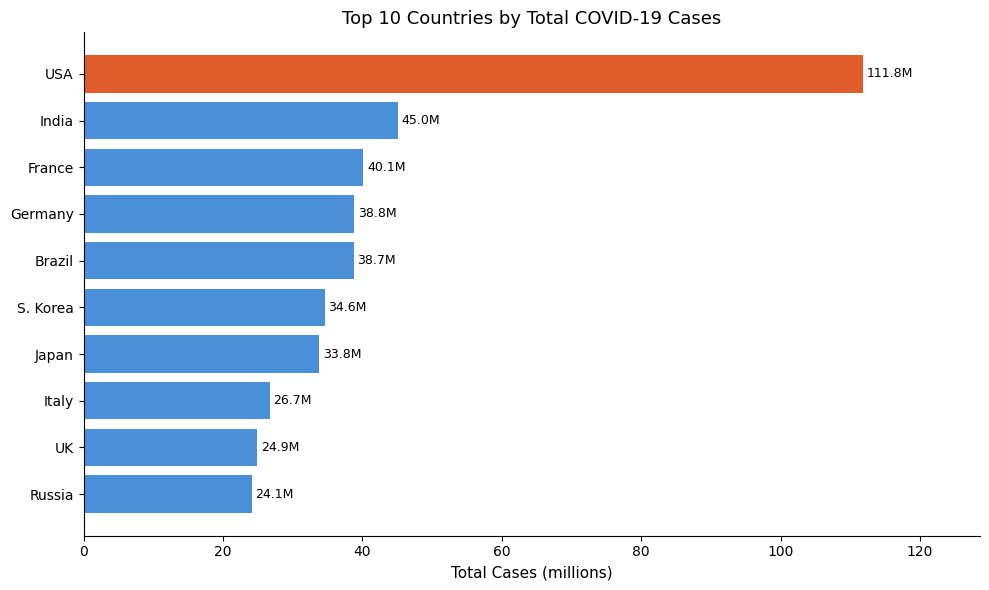

Saved: chart1_top10_cases.png ✓


In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#e05c2a" if c == "USA" else "#4a90d9" for c in top_cases["country"]]

bars = ax.barh(top_cases["country"], top_cases["cases"] / 1e6, color=colors)
ax.invert_yaxis()
ax.set_xlabel("Total Cases (millions)")
ax.set_title("Top 10 Countries by Total COVID-19 Cases")

# Value labels
for bar, val in zip(bars, top_cases["cases"] / 1e6):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}M", va="center", fontsize=9)

ax.set_xlim(0, top_cases["cases"].max() / 1e6 * 1.15)
plt.tight_layout()
plt.savefig("chart1_top10_cases.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart1_top10_cases.png ✓")

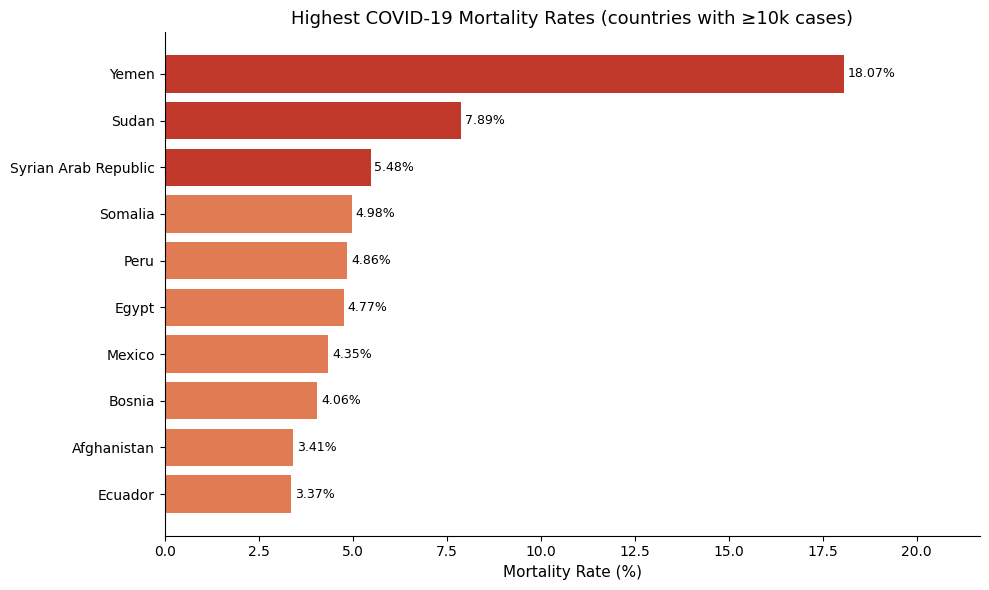

Saved: chart2_mortality_rate.png ✓


In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#c0392b" if r > 5 else "#e07b54" if r > 3 else "#f0a070"
          for r in high_mortality["mortality_rate"]]

bars = ax.barh(high_mortality["country"], high_mortality["mortality_rate"], color=colors)
ax.invert_yaxis()
ax.set_xlabel("Mortality Rate (%)")
ax.set_title("Highest COVID-19 Mortality Rates (countries with ≥10k cases)")

for bar, val in zip(bars, high_mortality["mortality_rate"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val}%", va="center", fontsize=9)

ax.set_xlim(0, high_mortality["mortality_rate"].max() * 1.2)
plt.tight_layout()
plt.savefig("chart2_mortality_rate.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart2_mortality_rate.png ✓")

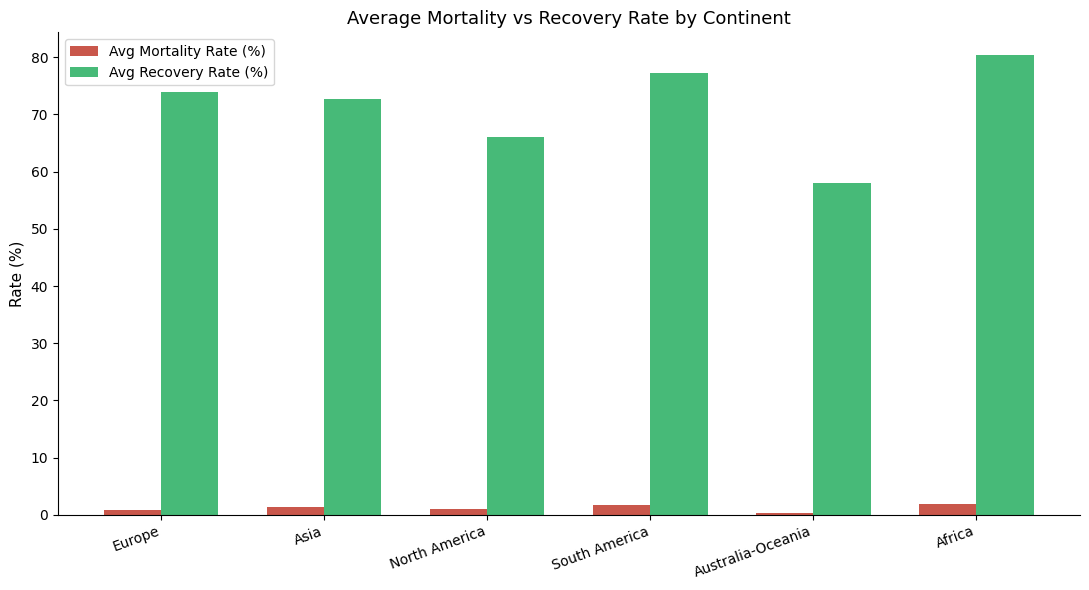

Saved: chart3_continental_rates.png ✓


In [19]:
fig, ax = plt.subplots(figsize=(11, 6))

x = range(len(continent_summary))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], continent_summary["avg_mortality_rate"],
               width, label="Avg Mortality Rate (%)", color="#c0392b", alpha=0.85)
bars2 = ax.bar([i + width/2 for i in x], continent_summary["avg_recovery_rate"],
               width, label="Avg Recovery Rate (%)", color="#27ae60", alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(continent_summary["continent"], rotation=20, ha="right")
ax.set_ylabel("Rate (%)")
ax.set_title("Average Mortality vs Recovery Rate by Continent")
ax.legend()

plt.tight_layout()
plt.savefig("chart3_continental_rates.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart3_continental_rates.png ✓")

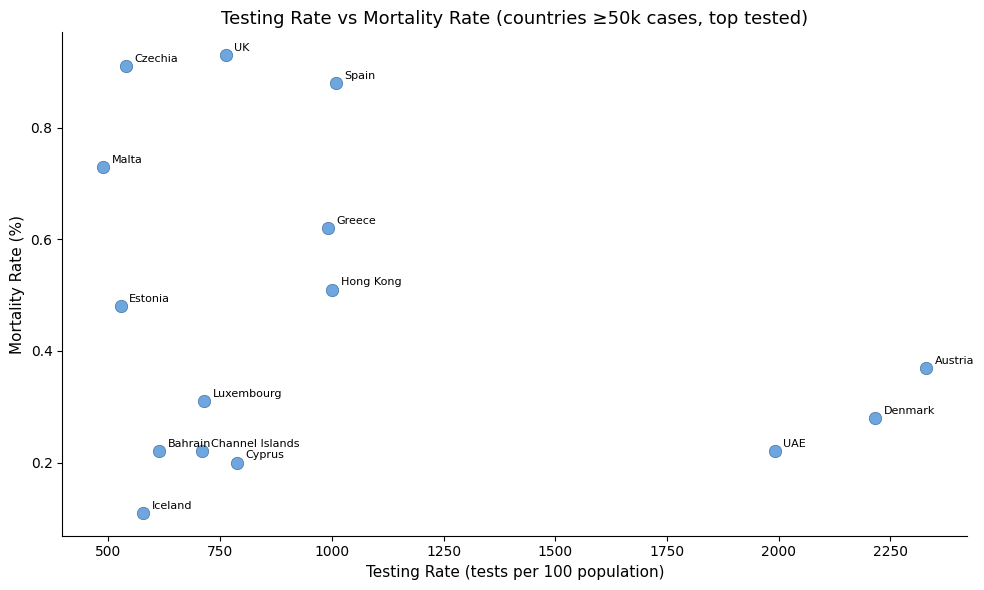

Saved: chart4_testing_vs_mortality.png ✓


In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(testing_vs_mortality["testing_rate_pct"],
           testing_vs_mortality["mortality_rate"],
           color="#4a90d9", s=80, alpha=0.8, edgecolors="#2c5f8a", linewidths=0.5)

# Label each point
for _, row in testing_vs_mortality.iterrows():
    ax.annotate(row["country"],
                (row["testing_rate_pct"], row["mortality_rate"]),
                textcoords="offset points", xytext=(6, 3), fontsize=8)

ax.set_xlabel("Testing Rate (tests per 100 population)")
ax.set_ylabel("Mortality Rate (%)")
ax.set_title("Testing Rate vs Mortality Rate (countries ≥50k cases, top tested)")

plt.tight_layout()
plt.savefig("chart4_testing_vs_mortality.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart4_testing_vs_mortality.png ✓")

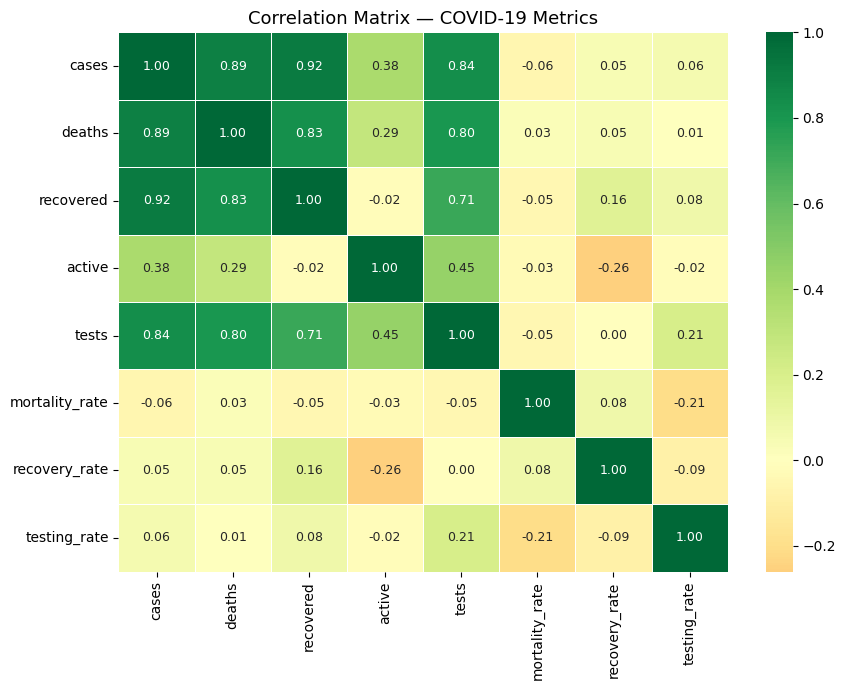

Saved: chart5_correlation_heatmap.png ✓


In [21]:
fig, ax = plt.subplots(figsize=(9, 7))

cols = ["cases", "deaths", "recovered", "active", "tests",
        "mortality_rate", "recovery_rate", "testing_rate"]

corr = df[cols].corr().round(2)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn",
            center=0, linewidths=0.5, ax=ax,
            annot_kws={"size": 9})

ax.set_title("Correlation Matrix — COVID-19 Metrics")
plt.tight_layout()
plt.savefig("chart5_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: chart5_correlation_heatmap.png ✓")

In [22]:
conn.close()
print("SQLite connection closed ✓")
print("\nAll outputs:")
print("  • covid_pipeline.db")
print("  • chart1_top10_cases.png")
print("  • chart2_mortality_rate.png")
print("  • chart3_continental_rates.png")
print("  • chart4_testing_vs_mortality.png")
print("  • chart5_correlation_heatmap.png")

SQLite connection closed ✓

All outputs:
  • covid_pipeline.db
  • chart1_top10_cases.png
  • chart2_mortality_rate.png
  • chart3_continental_rates.png
  • chart4_testing_vs_mortality.png
  • chart5_correlation_heatmap.png


In [23]:
import os

files = [
    "covid_pipeline.db",
    "chart1_top10_cases.png",
    "chart2_mortality_rate.png",
    "chart3_continental_rates.png",
    "chart4_testing_vs_mortality.png",
    "chart5_correlation_heatmap.png",
]

for f in files:
    status = "✓" if os.path.exists(f) else "✗ MISSING"
    print(f"  {status}  {f}")

  ✓  covid_pipeline.db
  ✓  chart1_top10_cases.png
  ✓  chart2_mortality_rate.png
  ✓  chart3_continental_rates.png
  ✓  chart4_testing_vs_mortality.png
  ✓  chart5_correlation_heatmap.png
